# Demonstration: Reproducing spectral statistics of beta ensembles

In this notebook, we will confirm that spectra generated by beta_ensembles agree with the expected distributions for spacings and spacing ratios, and demonstrate basic usage of the package.

In [1]:
# General imports
import numpy as np
import scipy
import matplotlib.pyplot as plt

# Insert path of source folder
import sys
from pathlib import Path
root_dir = Path.cwd().parent
sys.path.insert(0, str(root_dir / "src"))

# And import the Package:
import beta_ensembles as be

# Default plotting style
plt.style.use(['seaborn-v0_8','./plot_style.mplstyle'])

# Default path to save figures
def savefig(fname):
    plt.savefig(str(Path.cwd().parent) + '\\figures\\' + fname + '.png')

In [2]:
# Auxiliary function to plot spectral density and spacing distributions
def plot_all(bins1=200,bins2=200,bins3=200,bins4=200):
    fig, ax = plt.subplots(2,2,figsize=(10,8))
    
    plt.subplot(2,2,1)
    be.plot.hist(spectra,bins=bins1);
    
    plt.xlabel(r'$\lambda$')
    plt.ylabel(r'$\rho(\lambda)$')
    plt.title("Eigenvalue density before unfolding")
    # plt.ylim(0,0.02)
    
    plt.subplot(2,2,2)
    be.plot.hist(unfolded,bins=bins2);
    plt.xlabel(r'$z$')
    plt.ylabel(r'$\rho(z)$')
    
    plt.axhline(1/N,0,N,c='r',ls='--')
    plt.title("Eigenvalue density after unfolding")
        
    plt.subplot(2,2,3)
    be.plot.hist_s(spacings,bins=bins3)
    be.plot.pdf_s(beta,c='r',ls='--')
    plt.xlim(0,3)
    plt.title("Distribution of spacings")
    plt.legend()
    
    plt.subplot(2,2,4)
    be.plot.hist_r(ratios,bins=bins4)
    be.plot.pdf_r(beta,c='r',ls='--')
    plt.title("Distribution of ratios")
    plt.legend()
    
    plt.tight_layout()

# Gaussian ensembles

We start with the Gaussian beta-ensemble. We show that they follow the semicircle distribution, and use the cumulative distribution to unfold the spectra. After unfolding, we can match the distributions of nearest-neighbor spacings and their ratios with the expected distributions of the beta ensembles.

First we set the parameters beta and N, and generate a large number of spectra.

Each spectrum is unfolded using the analytic semicircle formula. The spacings and ratios are computed from the unfolded eigenvalues.

In [3]:
# Set rng for exact reproducibility
rng = np.random.default_rng(seed=sum(b"Matcha mochi"))

# Set parameters
beta = 1.5
N = 100
n_spectra = 2000

# Generate spectra of eigenvalues from the GBE
spectra = be.gaussian.spectra(beta,N,n_spectra,rng=rng)

# Unfold and get spacings and ratios
unfolded = be.gaussian.unfold(spectra)
spacings = be.spacings(unfolded)
ratios = be.ratios(unfolded)

Generating GBE spectra: 100%|████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 2251.95it/s]


Let's plot the results.

This is figure 5.1 in the arXiv note.

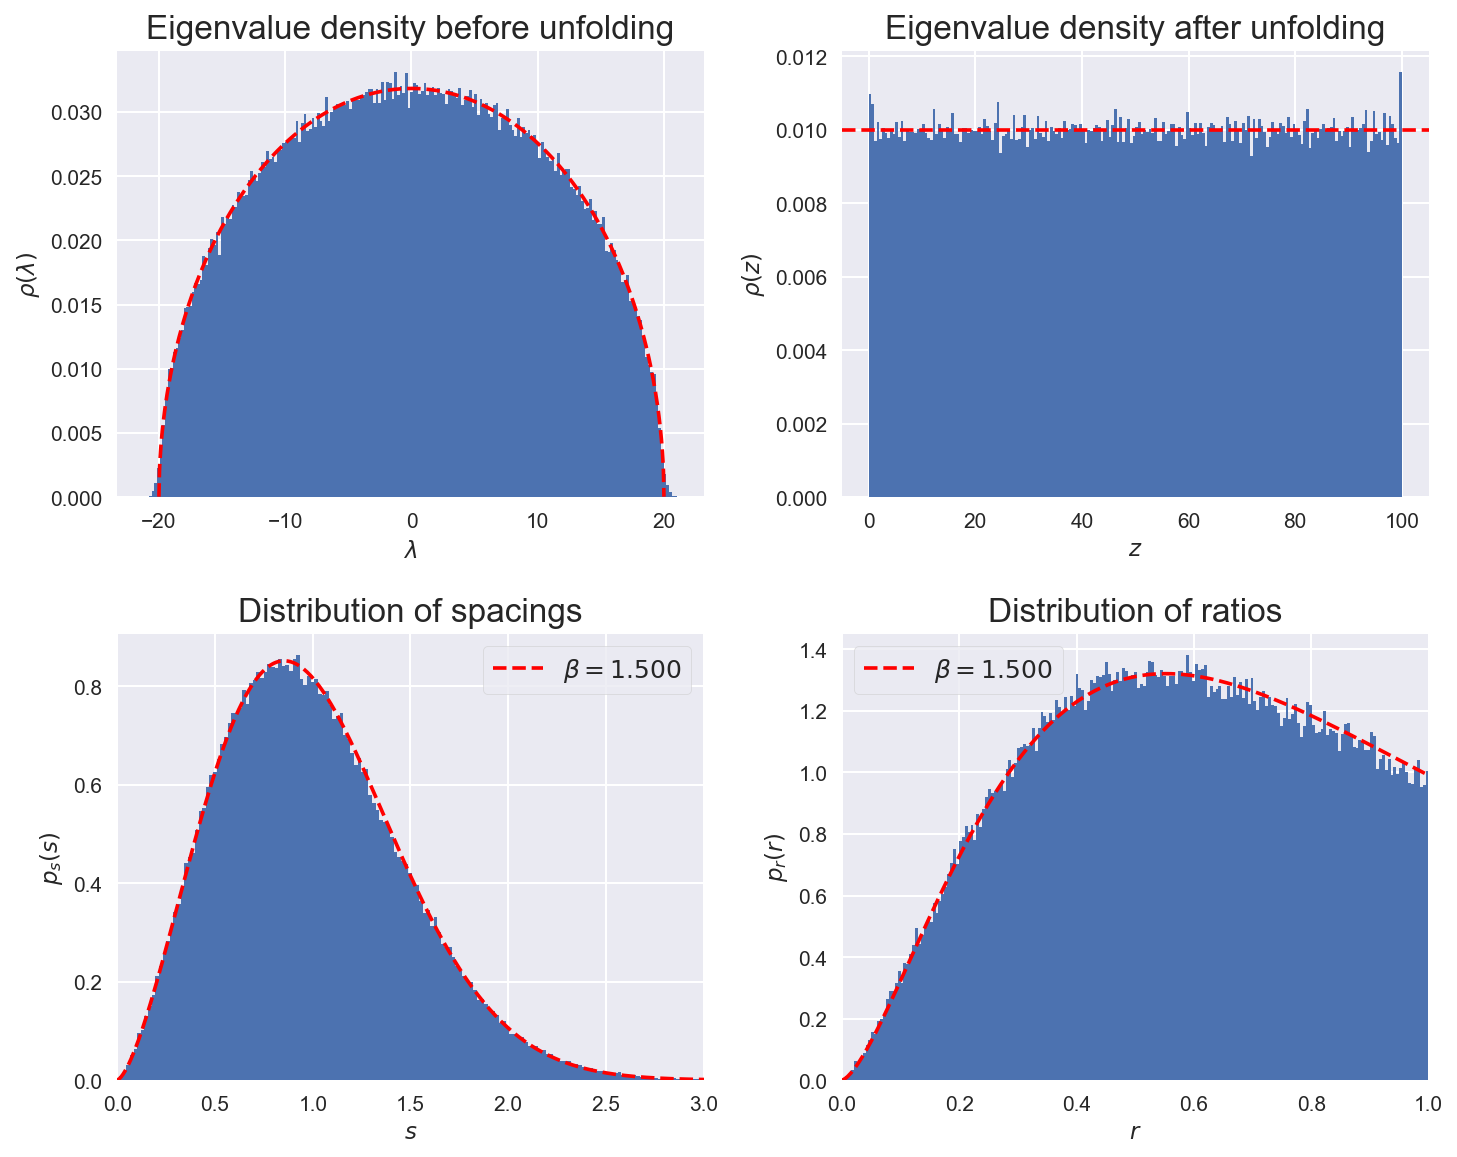

In [4]:
plot_all()

# Add expected semicircle density to the first plot
plt.subplot(2,2,1)
be.plot.semicircle(N,c='r',ls='--')

# Save figure:
# savefig('0_gbe_temp')

The results match the theory almost exactly.

Some observations:

1) Unfolding the spectra using the semicircle formula will result in a nearly flat density function (for large enough N).

2) The unfolding procedure uses the analytic semicircle formula. Points outside the semicircle, which appear at finite probability at finite N, are mapped to z = 0 and N in the unfolding. As a result, there's a noticeable excess of values at the points z = 0 and N after unfolding. This is an unwanted edge effect, and should be dealt with for the best results. However, the number of offending eigenvalues is relatively small and the effect is negligible, at least for the present purpose where we don't require high precision.

4) The spacings of the *unfolded* spectra match the Wigner-Dyson distribution with the chosen value of beta.

5) The result for the spacing ratio would have matched the Atas-Bogomolny-Giraud-Roux surmise even without unfolding, as one can verify by writing a few more lines of code.

# Circular ensembles

We move on to the Circular beta-ensemble.

Here we work with the eigenphases: the eigenvalues of unitary matrices are on the unit circle and we take only their phase. By default be.circular.spectra(...) returns the phases only.

The unfolding in the Circular ensemble case is a trivial procedure of shifting and rescaling the eigenvalues. This is done by default by the function be.circular.spectra, but here we turned it off for the purposes of illustration.

After this simple rescaling, we can directly match the distributions of nearest-neighbor spacings and their ratios with the expected distributions of the beta ensembles, provided that N is large enough.

First we set the parameters beta and N, and generate a large number of spectra.

The disadvantage of the CBE is that the algorithm for generating spectra is relatively slower than for the GBE, causing longer runtimes for large N.

In [5]:
# Set rng for reproducibility
rng = np.random.default_rng(seed=sum(b"Houjicha parfait"))

# Set parameters
beta = 1.5
N = 100

n_spectra = 2000

# Generate spectra
# We set the option normalize=False to override default behavior and return the "raw" eigenphases, in the range [-pi,pi]
spectra = be.circular.spectra(beta,N,n_spectra,rng=rng,normalize=False)

# The unfolding is a trivial rescaling of the eigenphases from [-pi,pi] to [0,N]:
unfolded = be.circular.unfold(spectra)

spacings = be.spacings(unfolded)
ratios = be.ratios(unfolded)

Generating CBE spectra: 100%|██████████████████████████████████████████████████████| 2000/2000 [00:28<00:00, 71.09it/s]


Let's plot the same histrograms for the spectral density, the spacings, and the spacing ratios.

One observation is that here the unfolded spectra do not suffer from any edge effects. Unlike in the Gaussian case, There's nothing special going on at the points z = 0 or z = N.

This is figure 5.2.

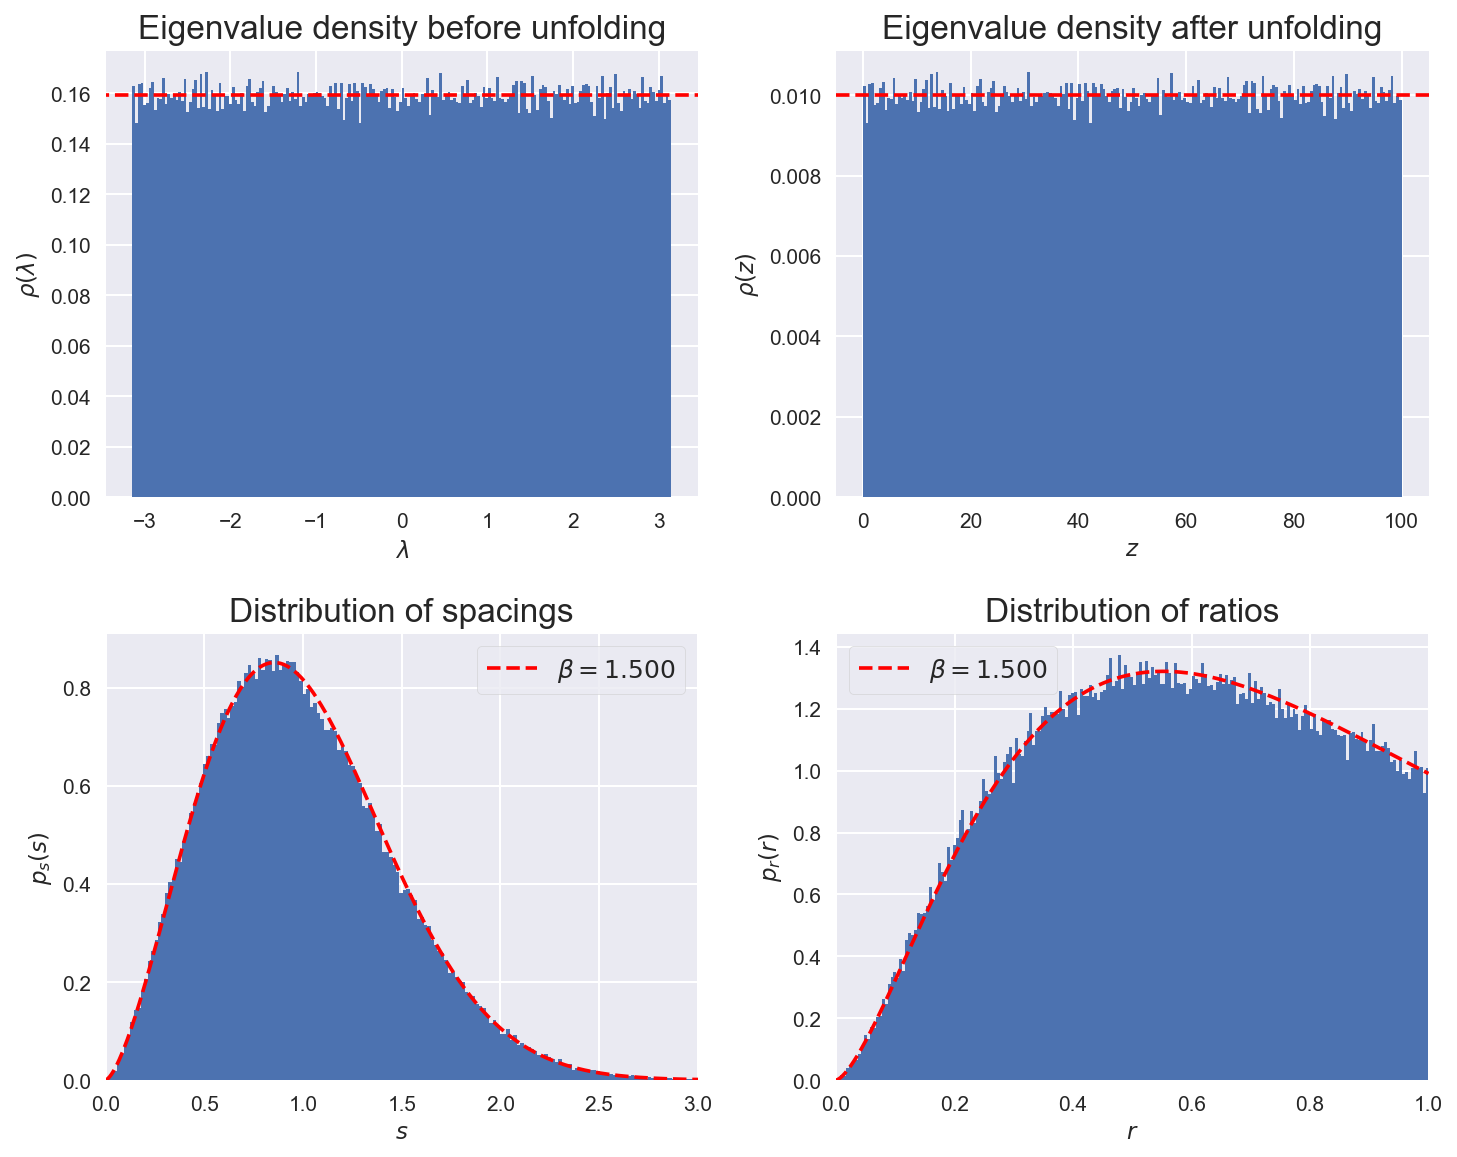

In [6]:
plot_all()

plt.subplot(2,2,1)
plt.axhline(1/2/np.pi,-np.pi,np.pi,c='r',ls='--')

# Save figure
# savefig('0_cbe_temp')

# Laguerre ensembles

For the Laguerre ensemble there is an additional parameter alpha. The shape of the limiting Marchenko-Pastur distribution depends on this parameter, so we examine two values separately, alpha = 1 and a large value alpha = 500.

In [7]:
# Set parameters
n_spectra = 2000

N = 100
beta = 1.5

# Choose alpha
alpha = 1
# alpha = 500

# Set rng for reproducibility
# (alpha added so we don't use the same seed for both samples.
# This is not at all necessary for our purposes, but we can afford to be pedantic.)
rng = np.random.default_rng(seed=sum(b"Melon kakigouri")+round(alpha))


# Generate spectra
spectra = be.laguerre.spectra(beta,alpha,N,n_spectra,rng=rng)

# Unfold and computing spacings and ratios
unfolded = be.laguerre.unfold(spectra,beta,alpha,N)

spacings = be.spacings(unfolded)
ratios = be.ratios(unfolded)

Generating LBE spectra: 100%|█████████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 849.89it/s]


Let us see the standard histograms. This is figure 5.3 and 5.4 (depending on alpha).

As in the GBE case, we can see the match with the expected eigenvalue density function (here the Marchenko-Pastur law), the edge effects of the unfolding manifesting as an excess of eigenvalues at the endpoints, and how the spacings and ratios fit.

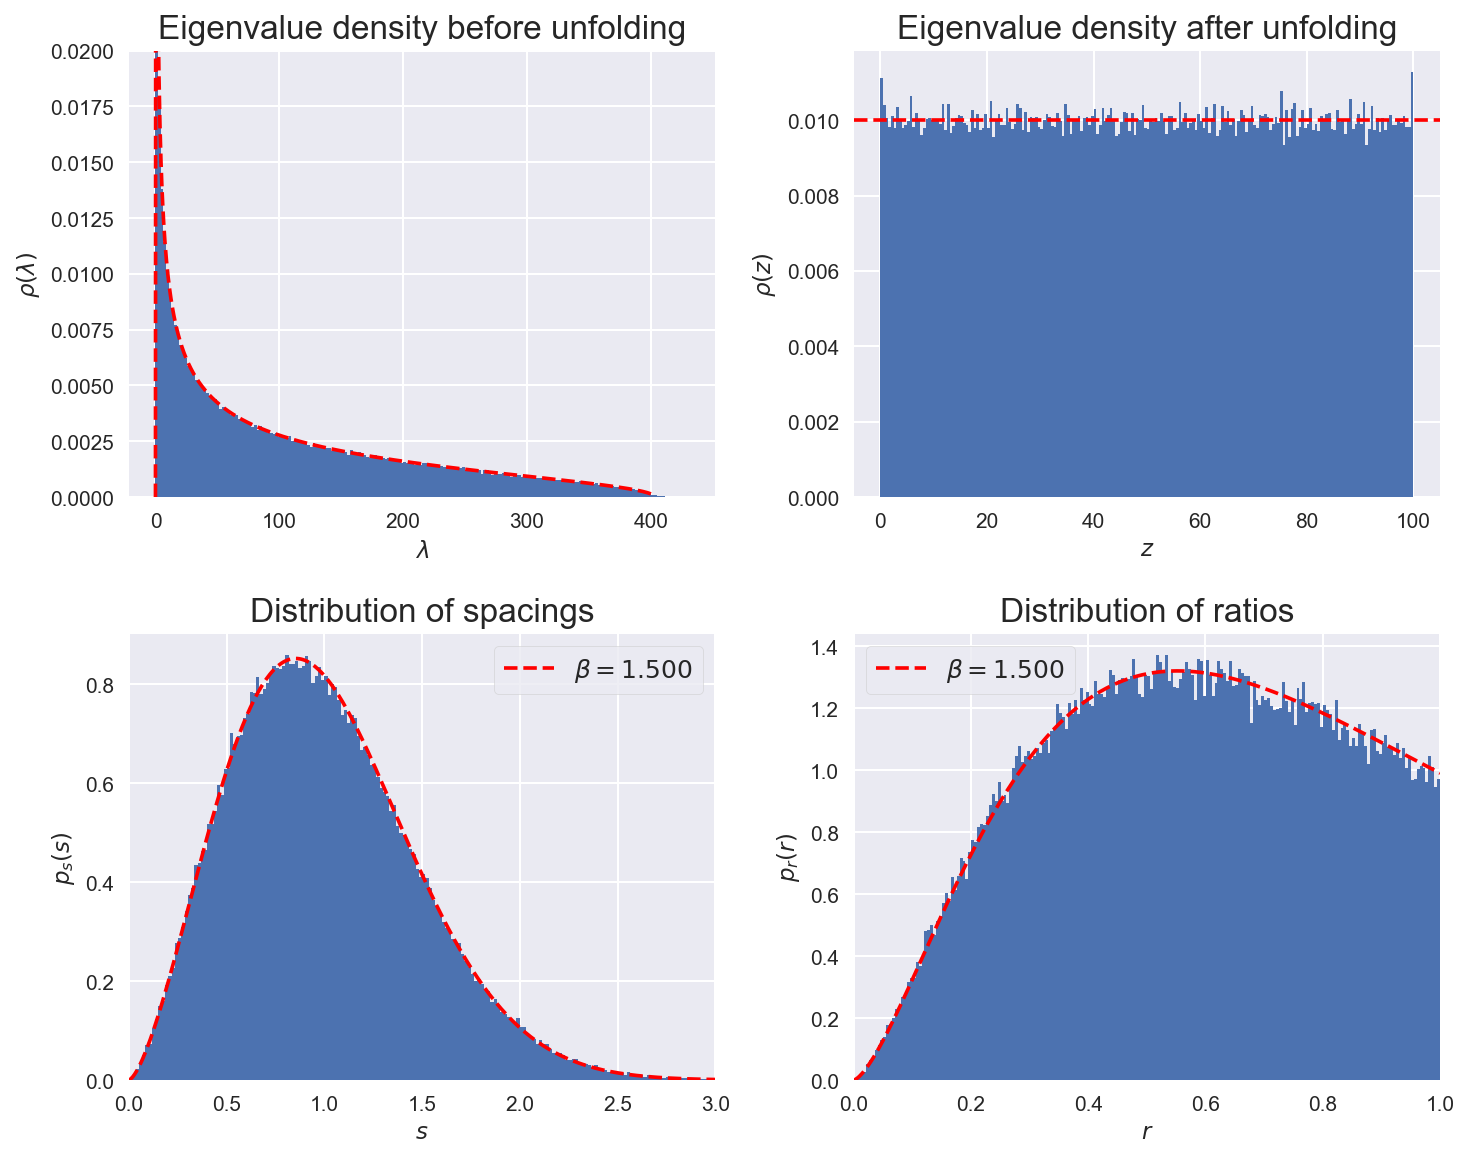

In [8]:
plot_all()

plt.subplot(2,2,1)
# Add the Marchenko-Pastur distribution. The shape parameter is computed automatically from beta, alpha, and N.
be.plot.MarchenkoPastur(beta,alpha,N,c='r',ls='--')
if alpha == 1:
    plt.ylim(0,0.02)

# Save figure
# savefig(f'0_lbe_{alpha}_temp')

# Large beta

The two examples below are for GBE and LBE spectra with values of the parameters in which we get more exotic behaviors. Specifically, we look at large beta, and see that the eigenvalue density has significant fluctuations. Even so, using the limiting semicircle and Marchenko-Pastur distributions to unfold the spectra works like a charm!

Generating GBE spectra: 100%|████████████████████████████████████████████████████| 2000/2000 [00:01<00:00, 1952.31it/s]


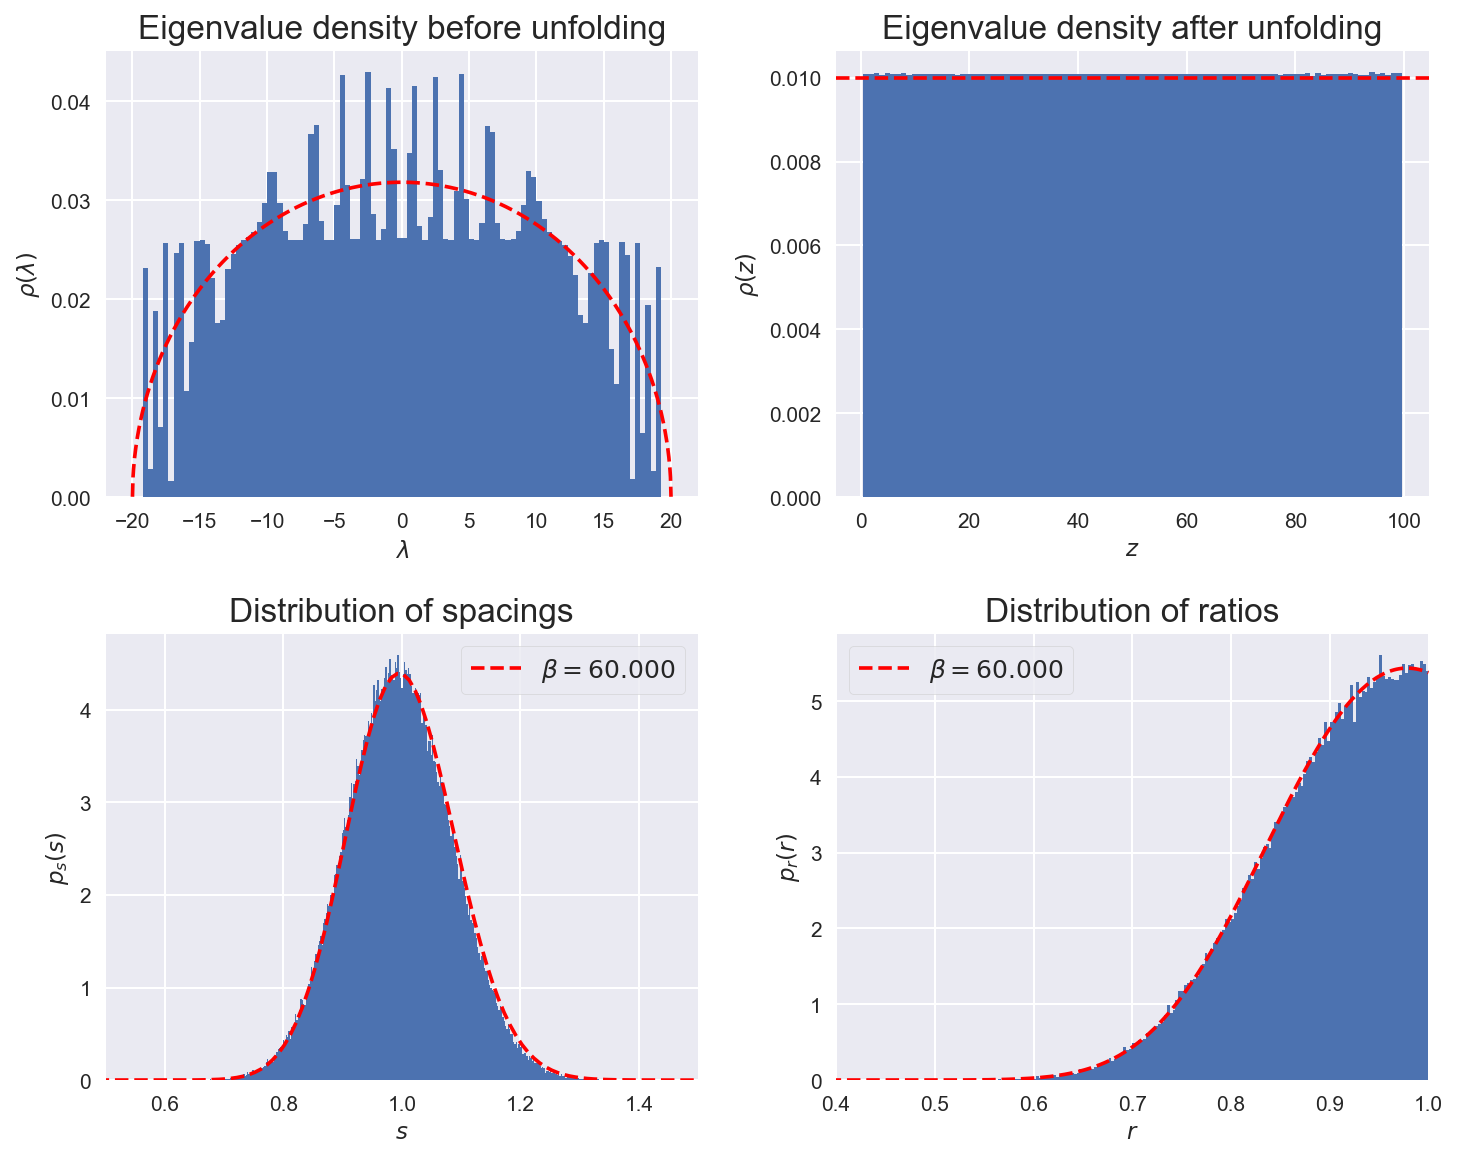

In [9]:
# Set rng for reproducibility
rng = np.random.default_rng(seed=sum(b"Sata andagi"))

beta = 60
N = 100

n_spectra = 2000

# Get spectra of eigenvalues from the GBE
spectra = be.gaussian.spectra(beta,N,n_spectra,rng=rng)

unfolded = be.gaussian.unfold(spectra)
spacings = be.spacings(unfolded)
ratios = be.ratios(unfolded)

plot_all(bins1=100,bins2=100,bins3=400)

plt.subplot(2,2,1)
be.plot.semicircle(N,c='r',ls='--')

plt.subplot(2,2,3)
plt.xlim(0.5,1.5)

plt.subplot(2,2,4)
plt.xlim(0.4,1.0);

For the Laguerre ensembles we found the following amusing example. The eigenvalues density looks almost as if it suffers from numerical artifacts (one can change the number of bins below to see how different it looks at different resolutioins). And yet the spacing and ratio distributions agree perfectly with the beta-ensmbles prediction!

Generating LBE spectra: 100%|████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 2023.02it/s]


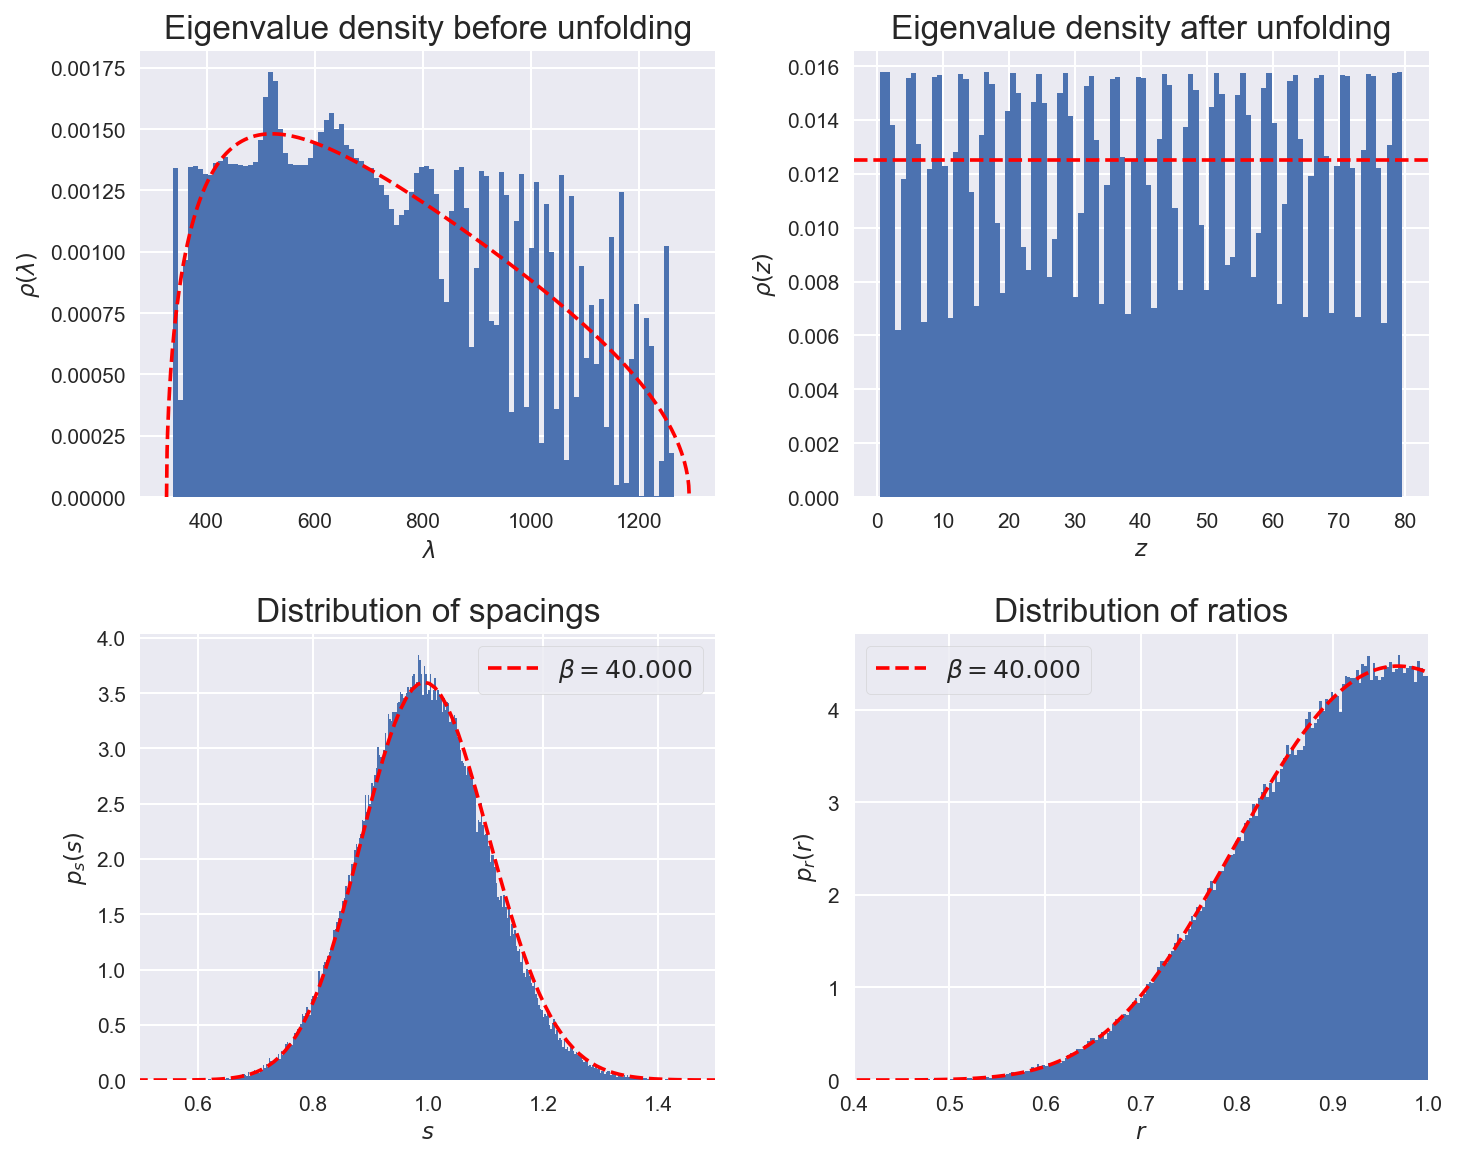

In [10]:
# Set rng for reproducibility
rng = np.random.default_rng(seed=sum(b"No, thanks, I'm full."))

beta = 40
N = 80

alpha = 13000

n_spectra = 2000

# Get spectra of eigenvalues from the GBE
spectra = be.laguerre.spectra(beta,alpha,N,n_spectra,rng=rng)

unfolded = be.laguerre.unfold(spectra,beta,alpha,N)
spacings = be.spacings(unfolded)
ratios = be.ratios(unfolded)

plot_all(bins1=100,bins2=100,bins3=400)

plt.subplot(2,2,1)
be.plot.MarchenkoPastur(beta,alpha,N,c='r',ls='--')

plt.subplot(2,2,3)
plt.xlim(0.5,1.5)

plt.subplot(2,2,4)
plt.xlim(0.4,1.0)

plt.show()